In [5]:
import numpy as np
import pandas as pd

import glob

# import the functions from the fitting module
#from dofitPython_functions import *

# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
#import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
#import cal_NSD as CN  # CN takes diameter in nanometers
import matplotlib.font_manager as font_manager
import warnings
warnings.simplefilter('ignore')
import glob
import multiprocessing

In [8]:
def predict_amm(df):
        'Function that takes a dataframe with datetime index'
        "Column names should be as below, (order does not matter)" 
        #[Org', 'NO3', 'SO4', 'NH4', 'Chl']
        # The function calculate and timeseries of Predicted ammonia in gram per cubic meters
        
        ##..............Molar mass in g/mol...............##
        mso4 = 96.06
        mno3 = 62
        mNH4 = 18
        to_grams = 10**(-6)
        data_g = df*to_grams
        ##...............Predicted ammonia and ammonium compounds...........##
        pred_NH4 = (2*(data_g.SO4)/mso4 + data_g.NO3/mno3)*mNH4*1e6   #predicted ammonia in micrograms
        pred_NH4_moles = (2*(data_g.SO4)/mso4 + data_g.NO3/mno3)   #predicted ammonia in moles
        pred_NH4SO4 = (data_g.SO4/mso4)*132.14*1e6   #predicted ammonium sulphate in micrograms per cubic meters
        pred_NH4NO3 = (data_g.NO3/mno3)*80.043*1e6   #predicted ammonium nitrate in micrograms per cubic meters

        ##................Observed ammonia in grams and moles................##
        obs_NH4_moles = data_g.NH4/mNH4    #observed ammonia in moles
        obs_NH4 = data_g.NH4*1e6   #observed ammonia in micrograms per cubic meter

        obs_NH4_df = obs_NH4.to_frame(name = 'obsNH4')
        pred_NH4_df = pred_NH4.to_frame(name = 'predNH4')
        pred_obs_NH4 = pd.concat([obs_NH4_df, pred_NH4_df], axis = 1).dropna()
        
        pred_obs_NH41 = pred_obs_NH4.reset_index()
        pred_obs_NH41['datetime'] = pred_obs_NH41.datetime
        pred_obs_NH41['datetime'] = pd.to_datetime(pred_obs_NH41['datetime'])
        pred_obs_NH41.set_index('datetime', inplace = True)

        return [pred_obs_NH41, pred_NH4SO4, pred_NH4NO3]

In [30]:
def calculate_neutral_salts_gysel(org, so4, nh4, no3, eBC880=0.0):
    """
    Calculate neutral salt concentrations and kappa using Gysel's ion-pairing scheme (no chloride).
    
    Inputs (all in µg/m³):
        org     - Organic mass
        so4     - Sulfate mass (SO4²⁻)
        nh4     - Ammonium mass (NH4⁺)
        no3     - Nitrate mass (NO3⁻)
        eBC880  - Equivalent Black Carbon mass (default = 0)

    Returns:
        Dictionary with:
            - Mass of Org, NH4NO3, (NH4)2SO4, NH4HSO4, H2SO4, eBC880
            - 'kappa_volume_weighted'
    """

    # Molar masses [g/mol]
    MW = {
        'NH4': 18.04,
        'NO3': 62.00,
        'SO4': 96.06,
        'NH4NO3': 80.04,
        '(NH4)2SO4': 132.14,
        'NH4HSO4': 115.10,
        'H2SO4': 98.08
    }

    # Densities [g/cm³]
    density = {
        'Org': 1.50,         # Organics
        'NH4NO3': 1.72,
        '(NH4)2SO4': 1.77,
        'NH4HSO4': 1.78,
        'H2SO4': 1.83,
        'eBC880': 1.77       # Approx. soot density (or 1.80)
    }

    # Kappa values (literature-based)
    kappa = {
        'Org': 0.10,
        'NH4NO3': 0.67,
        '(NH4)2SO4': 0.61,
        'NH4HSO4': 0.61,
        'H2SO4': 0.90,
        'eBC880': 0.0        # Non-hygroscopic
    }

    # Convert to µmol/m³
    mol_nh4 = nh4 / MW['NH4']
    mol_no3 = no3 / MW['NO3']
    mol_so4 = so4 / MW['SO4']

    # Step 1: NH4NO3
    mol_nh4no3 = min(mol_nh4, mol_no3)
    mol_nh4 -= mol_nh4no3
    mol_no3 -= mol_nh4no3

    # Step 2: (NH4)2SO4
    mol_nh42so4 = min(mol_so4, mol_nh4 // 2)
    mol_so4 -= mol_nh42so4
    mol_nh4 -= 2 * mol_nh42so4

    # Step 3: NH4HSO4
    mol_nh4hso4 = min(mol_so4, mol_nh4)
    mol_so4 -= mol_nh4hso4
    mol_nh4 -= mol_nh4hso4

    # Step 4: Remaining SO4 → H2SO4
    mol_h2so4 = mol_so4

    # Convert to mass [µg/m³]
    mass = {
        'Org': org,
        'NH4NO3': mol_nh4no3 * MW['NH4NO3'],
        '(NH4)2SO4': mol_nh42so4 * MW['(NH4)2SO4'],
        'NH4HSO4': mol_nh4hso4 * MW['NH4HSO4'],
        'H2SO4': mol_h2so4 * MW['H2SO4'],
        'eBC880': eBC880
    }

    # Convert to volume [cm³/m³]
    volume = {key: mass[key] / density[key] for key in mass}
    total_volume = sum(volume.values())

    # Volume-weighted kappa
    kappa_calc = sum(volume[key] * kappa[key] for key in volume) / total_volume

    result = {**mass, 'kappa_volume_weighted': kappa_calc}
    return result



In [31]:
comp = pd.read_csv('refined_raw_data/ACSM_eBC_ON_mask.csv')
comp['datetime'] = pd.to_datetime(comp['datetime'])
comp.set_index('datetime', inplace = True)
comp

,Org,SO4,NH4,NO3,eBC880
datetime,,,,,
2016-08-12 21:00:00,1.162911,0.295114,0.001996,0.041768,0.146686
2016-08-12 22:00:00,1.385608,0.346939,0.136879,0.049796,0.092185
2016-08-12 23:00:00,1.314280,0.260620,0.018274,0.046408,0.083736
2016-08-13 00:00:00,0.999029,0.260756,0.193389,0.032062,0.109317
2016-08-13 01:00:00,1.320746,0.257967,0.195827,0.059085,0.084758
...,...,...,...,...,...
2020-04-01 10:00:00,0.173874,0.003531,0.004792,0.023168,0.043758
2020-04-01 15:00:00,0.115332,0.235586,0.149780,0.015971,0.038610
2020-04-01 16:00:00,0.017442,0.157964,0.054442,0.010820,0.038610


In [32]:
comp_final

,Org,SO4,NH4,NO3,eBC880,pred_NH4,obs_NH4,pred_NH4SO4,pred_NH4NO3,NH4NO3,(NH4)2SO4,NH4HSO4,H2SO4,kappa_volume_weighted
datetime,,,,,,,,,,,,,,
2016-08-12 21:00:00,1.162911,0.295114,0.001996,0.041768,0.146686,0.122725,0.001996,0.405958,0.053923,0.008857,0.0,0.000000,0.301320,0.242485
2016-08-12 22:00:00,1.385608,0.346939,0.136879,0.049796,0.092185,0.144478,0.136879,0.477249,0.064288,0.064285,0.0,0.415705,0.000000,0.217532
2016-08-12 23:00:00,1.314280,0.260620,0.018274,0.046408,0.083736,0.111145,0.018274,0.358508,0.059913,0.059911,0.0,0.030437,0.240164,0.226081
2016-08-13 00:00:00,0.999029,0.260756,0.193389,0.032062,0.109317,0.107031,0.193389,0.358696,0.041392,0.041390,0.0,0.312441,0.000000,0.219264
2016-08-13 01:00:00,1.320746,0.257967,0.195827,0.059085,0.084758,0.113831,0.195827,0.354859,0.076279,0.076277,0.0,0.309098,0.000000,0.203632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-01 10:00:00,0.173874,0.003531,0.004792,0.023168,0.043758,0.008049,0.004792,0.004857,0.029910,0.021261,0.0,0.000000,0.003605,0.166197
2020-04-01 15:00:00,0.115332,0.235586,0.149780,0.015971,0.038610,0.092926,0.149780,0.324072,0.020619,0.020618,0.0,0.282282,0.000000,0.454445
2020-04-01 16:00:00,0.017442,0.157964,0.054442,0.010820,0.038610,0.062341,0.054442,0.217296,0.013969,0.013968,0.0,0.189274,0.000000,0.566830


In [33]:
import os
# Define Extra dictionary to store additional parameters
Extra = {}

# Initialize the Kappa_switch to 0 by default
# Kappa_switch = 0 indicates that a fixed value of kappa (e.g., 0.18) will be used in calculations
#Extra['Kappa_switch'] = 0

# Change Kappa_switch to 1 when chemical composition is used to calculate kappa
# Kappa_switch = 1 signals that kappa should be calculated dynamically based on the chemical composition
Extra['Kappa_switch'] = 1

# Densities of various components (kg/m^3)
Extra['densities'] = [1.50*1e3, 1.77*1e3, 1.71*1e3, 1.77*1e3]
rho_org = Extra['densities'][0]
rho_sulp = Extra['densities'][1]
rho_nitr = Extra['densities'][2]
rho_bc = Extra['densities'][3]

Extra['kappa_org'] = 0.12  # Kappa value (hygroscopicity parameter) for organic compounds
Extra['kappa_NH4SO4'] = 0.61  # Kappa value (hygroscopicity parameter) for ammonium sulfate (NH4)2SO4
Extra['kappa_NH4NO3'] = 0.67  # Kappa value (hygroscopicity parameter) for ammonium nitrate NH4NO3
Extra['eBC'] = 0  # Kappa value (hygroscopicity parameter) for black carbon


def cal_kappa(Extra, mass):
    """
    Calculate the kappa hygroscopicity parameter for the particle based on its composition.

    Parameters:
    - Extra: dict
        Additional parameters such as densities and hygroscopicity values.
    - mass: list or array
        Mass concentrations of different particle components.

    Returns:
    - kappa: list
        List containing the total kappa value for particles and the kappa for inorganics.
    """
    # Extract densities from Extra is in kg/m3
    rho_org = Extra['densities'][0]   # Density of organic material
    rho_sulp = Extra['densities'][1]   # Density of ammonium sulfate
    rho_nitr = Extra['densities'][2]  # Density of ammonium nitrate
    rho_bc = Extra['densities'][3]   # Density of black carbon
    
    # Hygroscopicity values for different components
    k_Org = Extra['kappa_org']  # Kappa for organics
    k_N = Extra['kappa_NH4NO3']             # Kappa for ammonium nitrate
    k_s = Extra['kappa_NH4SO4']  
    k_bc = Extra['eBC']  # Kappa for black carbon (assumed non-hygroscopic)
    
    # Calculate total particle volume
    tot_vol = (
        mass[0]/rho_org +  # Volume of organic material
        mass[1]/rho_sulp + # Volume of inorganics
        mass[2]/rho_nitr + # Volume of ammonium nitrate
        mass[3]/rho_bc     # Volume of black carbon
    )

    # Calculate contributions to kappa from each component
    k1 = k_Org * (mass[0]/rho_org) / tot_vol  # Contribution from organics
    k2 = k_s * (mass[1]/rho_sulp) / tot_vol   # Contribution from inorganics
    k3 = k_N * (mass[2]/rho_nitr) / tot_vol   # Contribution from ammonium nitrate (is zero currently)
    k4 = k_bc * (mass[3]/rho_bc) / tot_vol

    # Total kappa value
    kappa = k1 + k2 + k3 + k4

    return kappa

In [38]:
def compute_kappas_two_methods(comp, Extra):
    """
    Compute two kappa values for each time point using the input composition:
    1. Kappa using Gysel's ion-pairing scheme.
    2. Kappa using simplified full neutralization (SO4/NO3 fully neutralized by NH4).

    Returns:
        pd.DataFrame with columns ['kappa_gysel', 'kappa_simple'] and datetime index.
    """
    import pandas as pd
    from tqdm import tqdm

    # Ensure required columns are present
    required_cols = ['Org', 'SO4', 'NH4', 'NO3', 'eBC880']
    df = comp[required_cols].copy()

    # --- Simplified Stoichiometric Neutralization ---
    pred_obs_NH4_df, pred_NH4SO4, pred_NH4NO3 = predict_amm(df)
    df['NH4SO4'] = pred_NH4SO4  # µg/m³
    df['NH4NO3'] = pred_NH4NO3  # µg/m³

    kappas_simple = []
    for _, row in df.iterrows():
        mass_vec = [
            row['Org'],      # organics
            row['NH4SO4'],   # ammonium sulfate
            row['NH4NO3'],   # ammonium nitrate
            row['eBC880']    # black carbon
        ]
        kappa_val = cal_kappa(Extra, mass_vec)
        kappas_simple.append(kappa_val)

    # --- Gysel Ion-Pairing Kappa ---
    tqdm.pandas()

    def gysel_wrapper(row):
        return calculate_neutral_salts_gysel(
            org=row['Org'],
            so4=row['SO4'],
            nh4=row['NH4'],
            no3=row['NO3'],
            eBC880=row['eBC880']
        )['kappa_volume_weighted']

    kappa_gysel = df.progress_apply(gysel_wrapper, axis=1)

    # --- Combine both into one dataframe ---
    kappa_df = pd.DataFrame({
        'kappa_gysel': kappa_gysel,
        'kappa_simple': kappas_simple
    }, index=comp.index)

    return kappa_df


In [39]:
kappa_df = compute_kappas_two_methods(comp, Extra)

100%|████████████████████████████████████████████████| 14912/14912 [00:00<00:00, 105410.56it/s]


In [40]:
kappa_df

,kappa_gysel,kappa_simple
datetime,,
2016-08-12 21:00:00,0.222936,0.227041
2016-08-12 22:00:00,0.208445,0.234218
2016-08-12 23:00:00,0.216416,0.217187
2016-08-13 00:00:00,0.204661,0.230201
2016-08-13 01:00:00,0.195126,0.219726
...,...,...
2020-04-01 10:00:00,0.139684,0.169717
2020-04-01 15:00:00,0.417631,0.438968
2020-04-01 16:00:00,0.483227,0.497369


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Set global font to bold and sans-serif
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

def plot_kappa_comparison(kappa_df):
    """
    Plot a scatter plot comparing two kappa estimation methods.
    """
    plt.figure(figsize=(7, 6))
    sns.set_style("white")  # Removes grid by default

    # Scatter plot
    plt.scatter(
        kappa_df['kappa_simple'],
        kappa_df['kappa_gysel'],
        color='steelblue',
        edgecolor='k',
        alpha=0.7
    )

    # 1:1 reference line
    min_val = min(kappa_df.min())
    max_val = max(kappa_df.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 line')

    # Labels
    plt.xlabel('Kappa (current method)', fontsize=16, fontweight='bold')
    plt.ylabel('Kappa (Gysel ion-pairing)', fontsize=16, fontweight='bold')

    # Ticks
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')

    # Legend
    plt.legend(loc='upper left', frameon=False, fontsize=14)

    # Customize spines
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig('../../Model_v2/inverse_modelling/CLUSTERS/ACCTEN/Nitrate_mask/final_versions/python_version-V2/figures/paper_figures/Gysel_vs_simple_netralization.png', dpi = 500)
    plt.show()


100%|████████████████████████████████████████████████| 14912/14912 [00:00<00:00, 103415.46it/s]


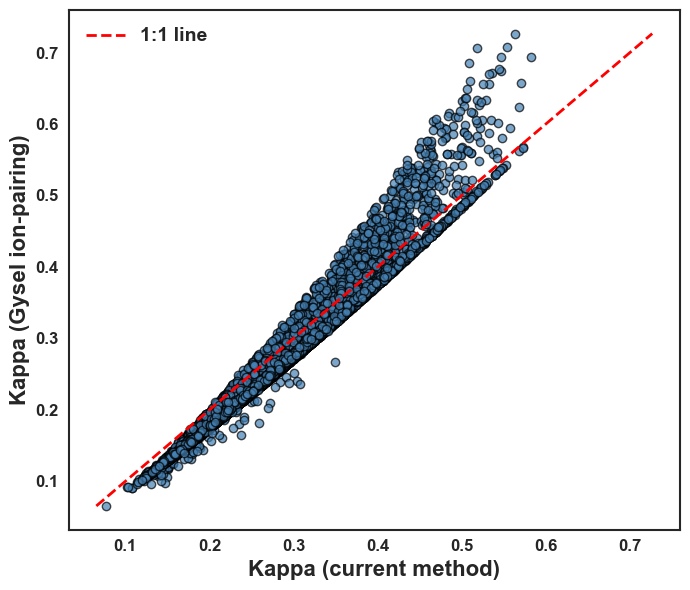

In [67]:
kappa_df = compute_kappas_two_methods(comp, Extra)
plot_kappa_comparison(kappa_df)

In [65]:
kappa_df.median(axis = 0)

kappa_gysel     0.213412
kappa_simple    0.235729
dtype: float64